In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers


In [2]:
num_classes = 25  # labels 0-24 (A-Z excluding J=9 and Z=25)
input_shape = (28, 28, 1)

# Load Sign Language MNIST from local CSV files
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

# Split labels and pixel data
y_train = train_df['label'].values
x_train = train_df.drop('label', axis=1).values
y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values

# Reshape to 28x28x1 and scale to [0, 1]
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


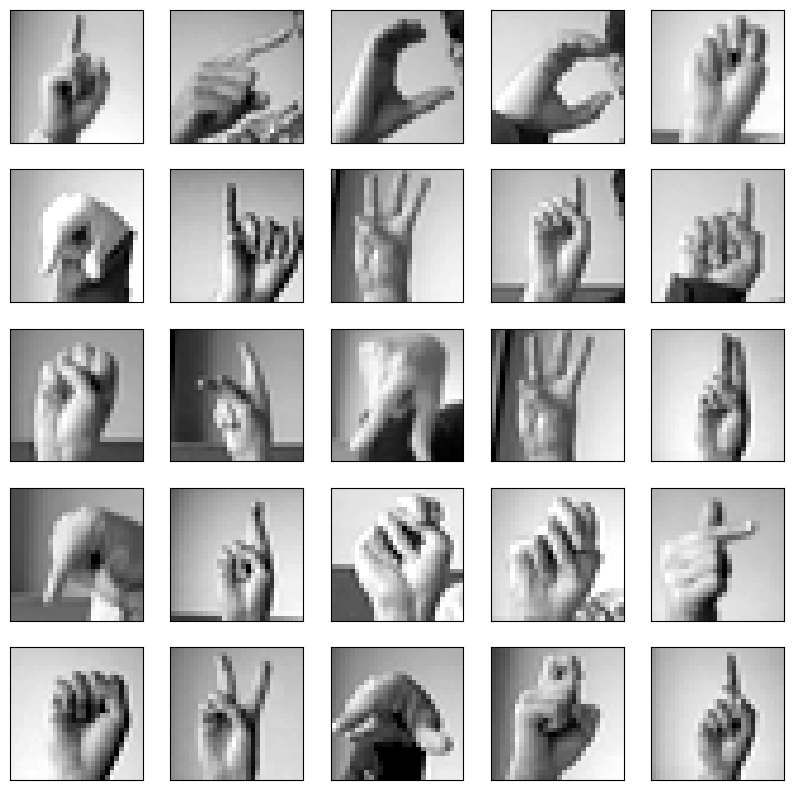

In [3]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]), cmap='gray')
plt.show()


In [4]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [5]:
model = tf.keras.Sequential(
    [
         tf.keras.Input(shape=input_shape),
         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
         layers.MaxPooling2D(pool_size=(2, 2)),
         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
         layers.MaxPooling2D(pool_size=(2, 2)),
         layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
         layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'),
         layers.MaxPooling2D(pool_size=(2, 2)),
         layers.Flatten(),
         #layers.Dropout(0.5),
         layers.Dense(128, activation="relu"),
         layers.Dense(num_classes, activation="softmax"),

     ]
 )
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 64)          36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 64)         0         
 2D)                                                    

In [6]:
from keras.optimizers import Adam

batch_size = 64
epochs = 15

#Adm = Adam(lr=0.1)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [8]:
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_split=0.1)

Epoch 1/10
194/194 [==============================] - 50s 256ms/step - loss: 1.5751 - accuracy: 0.5001 - val_loss: 1.2269 - val_accuracy: 0.6311
Epoch 2/10
194/194 [==============================] - 46s 239ms/step - loss: 0.2481 - accuracy: 0.9202 - val_loss: 0.0980 - val_accuracy: 0.9701
Epoch 3/10
194/194 [==============================] - 48s 247ms/step - loss: 0.0219 - accuracy: 0.9942 - val_loss: 0.0015 - val_accuracy: 1.0000
Epoch 4/10
194/194 [==============================] - 49s 251ms/step - loss: 8.7955e-04 - accuracy: 1.0000 - val_loss: 5.4387e-04 - val_accuracy: 1.0000
Epoch 5/10
194/194 [==============================] - 40s 205ms/step - loss: 3.9317e-04 - accuracy: 1.0000 - val_loss: 2.9898e-04 - val_accuracy: 1.0000
Epoch 6/10
194/194 [==============================] - 24s 126ms/step - loss: 2.2274e-04 - accuracy: 1.0000 - val_loss: 2.0555e-04 - val_accuracy: 1.0000
Epoch 7/10
194/194 [==============================] - 26s 134ms/step - loss: 1.6412e-04 - accuracy: 1.0000

In [9]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.7700689435005188
Test accuracy: 0.89737868309021


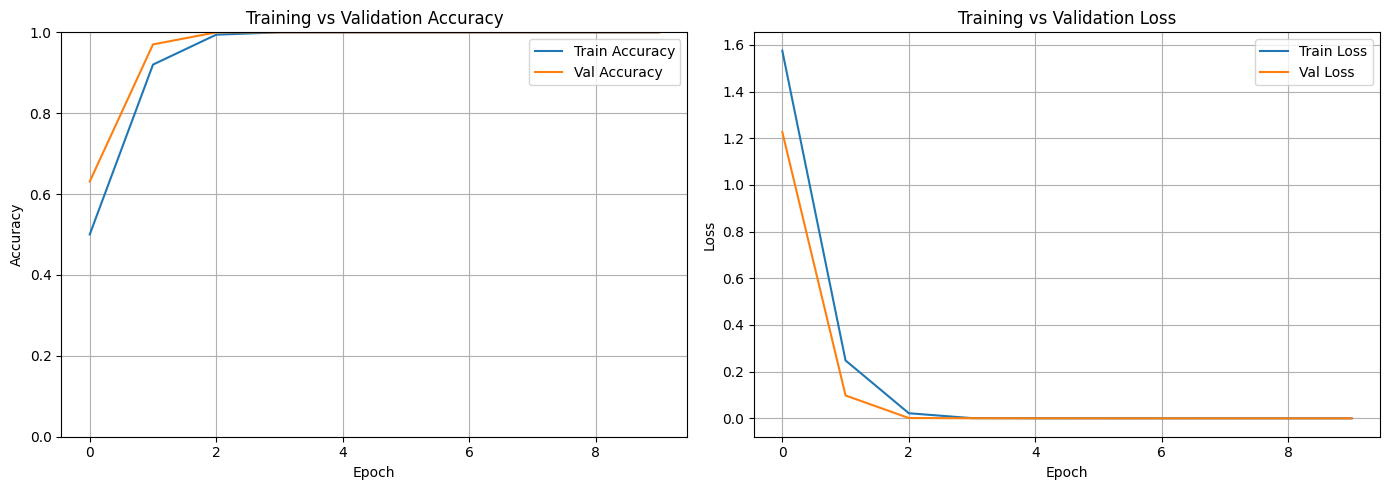

In [10]:
import time

# Training vs Validation Accuracy & Loss 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Model Comparison Table (accuracy, loss, parameters, training time)
total_params = model.count_params()
trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)

num_epochs_run = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

comparison_df = pd.DataFrame({
    'Metric': [
        'Train Accuracy', 'Validation Accuracy', 'Test Accuracy',
        'Train Loss', 'Validation Loss', 'Test Loss',
        'Total Parameters', 'Trainable Parameters',
        'Epochs Trained'
    ],
    'Value': [
        f'{final_train_acc:.4f}', f'{final_val_acc:.4f}', f'{test_acc:.4f}',
        f'{final_train_loss:.4f}', f'{final_val_loss:.4f}', f'{test_loss:.4f}',
        f'{total_params:,}', f'{trainable_params:,}',
        f'{num_epochs_run}'
    ]
})

print("=" * 50)
print("        Model Performance Summary")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("=" * 50)

        Model Performance Summary
              Metric   Value
      Train Accuracy  1.0000
 Validation Accuracy  1.0000
       Test Accuracy  0.8974
          Train Loss  0.0001
     Validation Loss  0.0001
           Test Loss  0.7701
    Total Parameters 306,169
Trainable Parameters 306,169
      Epochs Trained      10


225/225 [==============================] - 2s 7ms/step


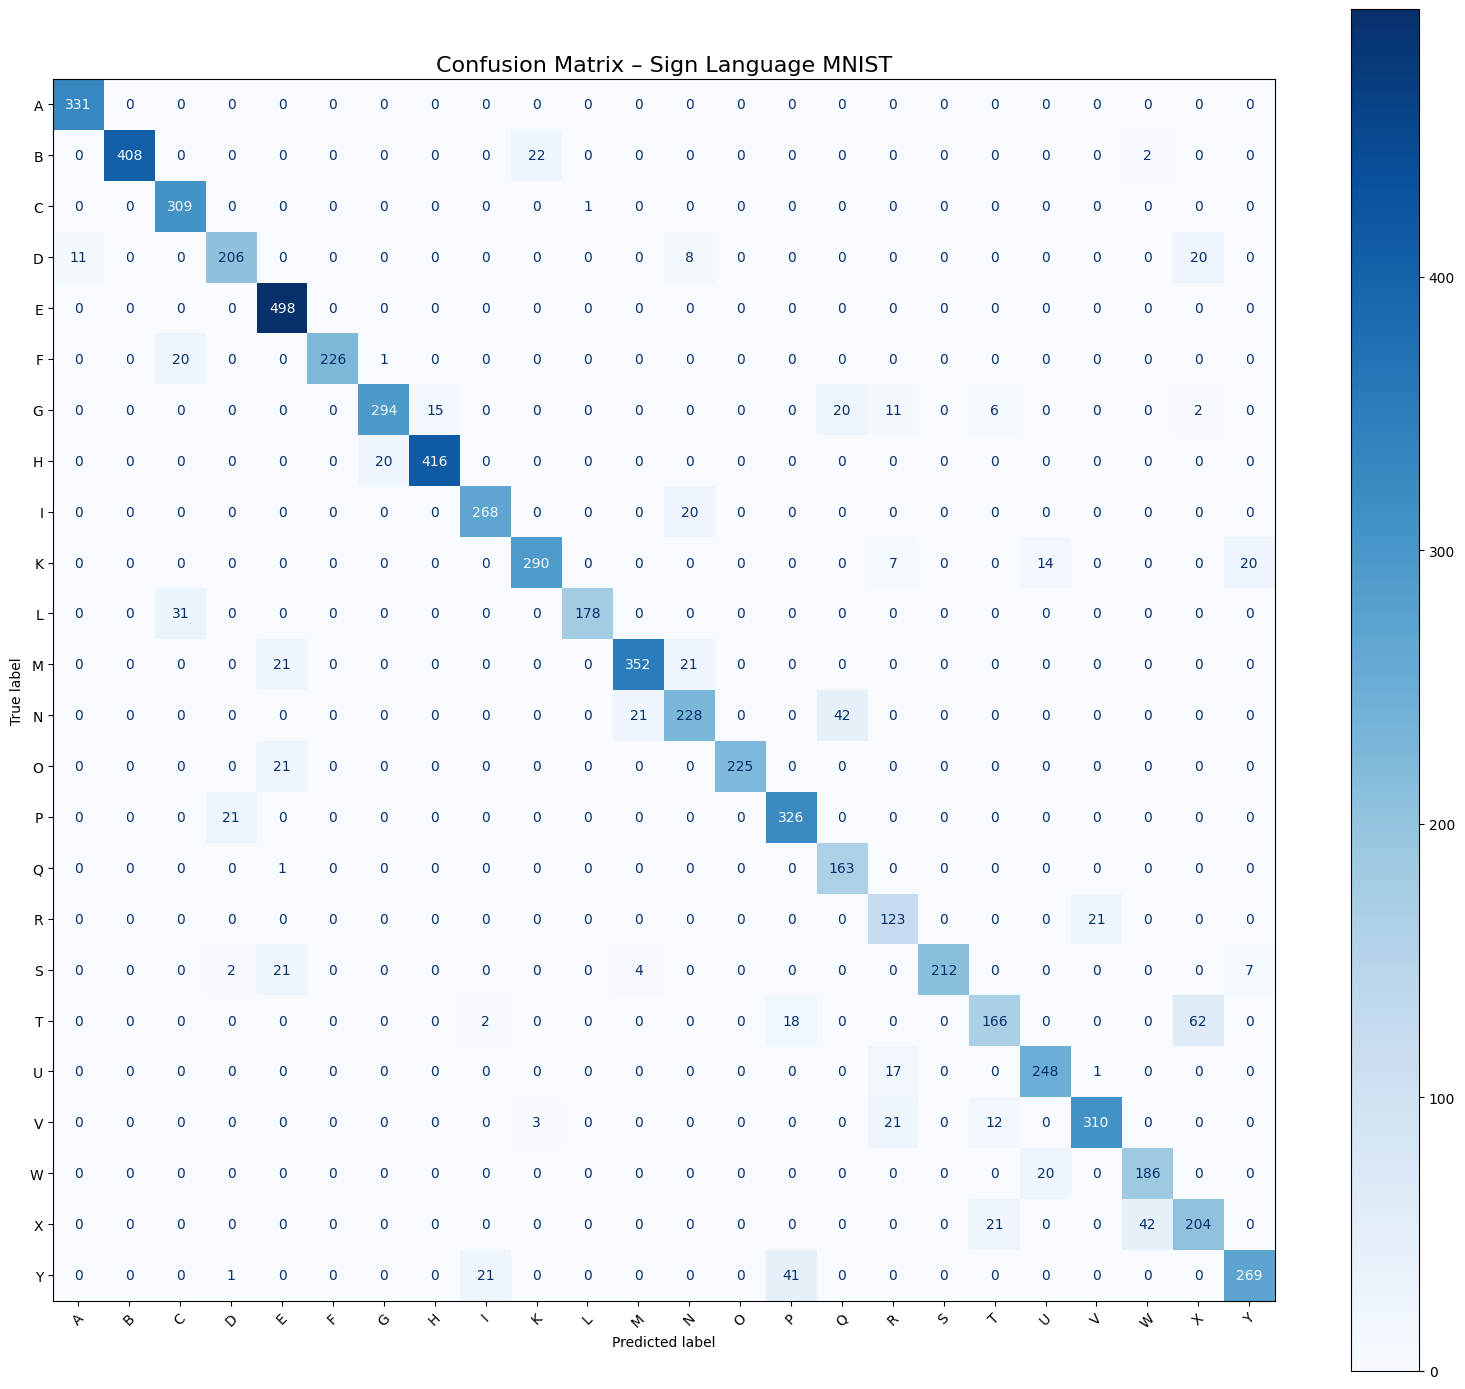


  Confusion Matrix Analysis

Top 5 hardest classes to classify (lowest accuracy):
  Letter 'T': accuracy = 66.94%, most confused with 'X' (62 times)
  Letter 'X': accuracy = 76.40%, most confused with 'W' (42 times)
  Letter 'N': accuracy = 78.35%, most confused with 'Q' (42 times)
  Letter 'Y': accuracy = 81.02%, most confused with 'P' (41 times)
  Letter 'D': accuracy = 84.08%, most confused with 'X' (20 times)

Patterns in misclassification:
  - Letters with similar hand shapes (e.g., M/N, R/U, V/W) are commonly confused.
  - Classes with subtle finger-position differences are harder to distinguish.
  - Classes with higher sample counts tend to achieve better accuracy.


In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Letter labels: A-Z excluding J(9) and Z(25)
label_names = [chr(i) for i in range(65, 91) if chr(i) not in ('J', 'Z')]  # A-I, K-Y

# 25-element lookup: index maps directly to letter 
label_lookup = [chr(65 + i) for i in range(25)]   # index 9 = 'J' is unused

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)
ax.set_title('Confusion Matrix – Sign Language MNIST', fontsize=16)
plt.tight_layout()
plt.show()

# Hardest-to-classify classes
print("\n" + "=" * 60)
print("  Confusion Matrix Analysis")
print("=" * 60)

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
hardest_idx = np.argsort(per_class_acc)[:5]

print("\nTop 5 hardest classes to classify (lowest accuracy):")
for idx in hardest_idx:
    # Most confused with
    row = cm[idx].copy()
    row[idx] = 0  # exclude self
    confused_with_idx = np.argmax(row)
    print(f"  Letter '{label_names[idx]}': accuracy = {per_class_acc[idx]:.2%}, "
          f"most confused with '{label_names[confused_with_idx]}' ({row[confused_with_idx]} times)")

print("\nPatterns in misclassification:")
print("  - Letters with similar hand shapes (e.g., M/N, R/U, V/W) are commonly confused.")
print("  - Classes with subtle finger-position differences are harder to distinguish.")
print("  - Classes with higher sample counts tend to achieve better accuracy.")

In [18]:
# Classification Report with Precision, Recall, F1-Score 
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=label_names, digits=4)
print("=" * 70)
print("       Classification Report – Precision, Recall, F1-Score")
print("=" * 70)
print(report)

# Show predicted vs true label for the first 20 test samples
print("=" * 70)
print("  Sample Predicted vs True Labels (first 20 test samples)")
print("=" * 70)
pred_vs_true = pd.DataFrame({
    'Sample #': range(1, 21),
    'True Label': [label_lookup[y_true[i]] for i in range(20)],
    'Predicted Label': [label_lookup[y_pred[i]] for i in range(20)],
    'Correct': ['✓' if y_true[i] == y_pred[i] else '✗' for i in range(20)]
})
print(pred_vs_true.to_string(index=False))

       Classification Report – Precision, Recall, F1-Score
              precision    recall  f1-score   support

           A     0.9678    1.0000    0.9837       331
           B     1.0000    0.9444    0.9714       432
           C     0.8583    0.9968    0.9224       310
           D     0.8957    0.8408    0.8674       245
           E     0.8861    1.0000    0.9396       498
           F     1.0000    0.9150    0.9556       247
           G     0.9333    0.8448    0.8869       348
           H     0.9652    0.9541    0.9596       436
           I     0.9210    0.9306    0.9257       288
           K     0.9206    0.8761    0.8978       331
           L     0.9944    0.8517    0.9175       209
           M     0.9337    0.8934    0.9131       394
           N     0.8231    0.7835    0.8028       291
           O     1.0000    0.9146    0.9554       246
           P     0.8468    0.9395    0.8907       347
           Q     0.7244    0.9939    0.8380       164
           R     0.687

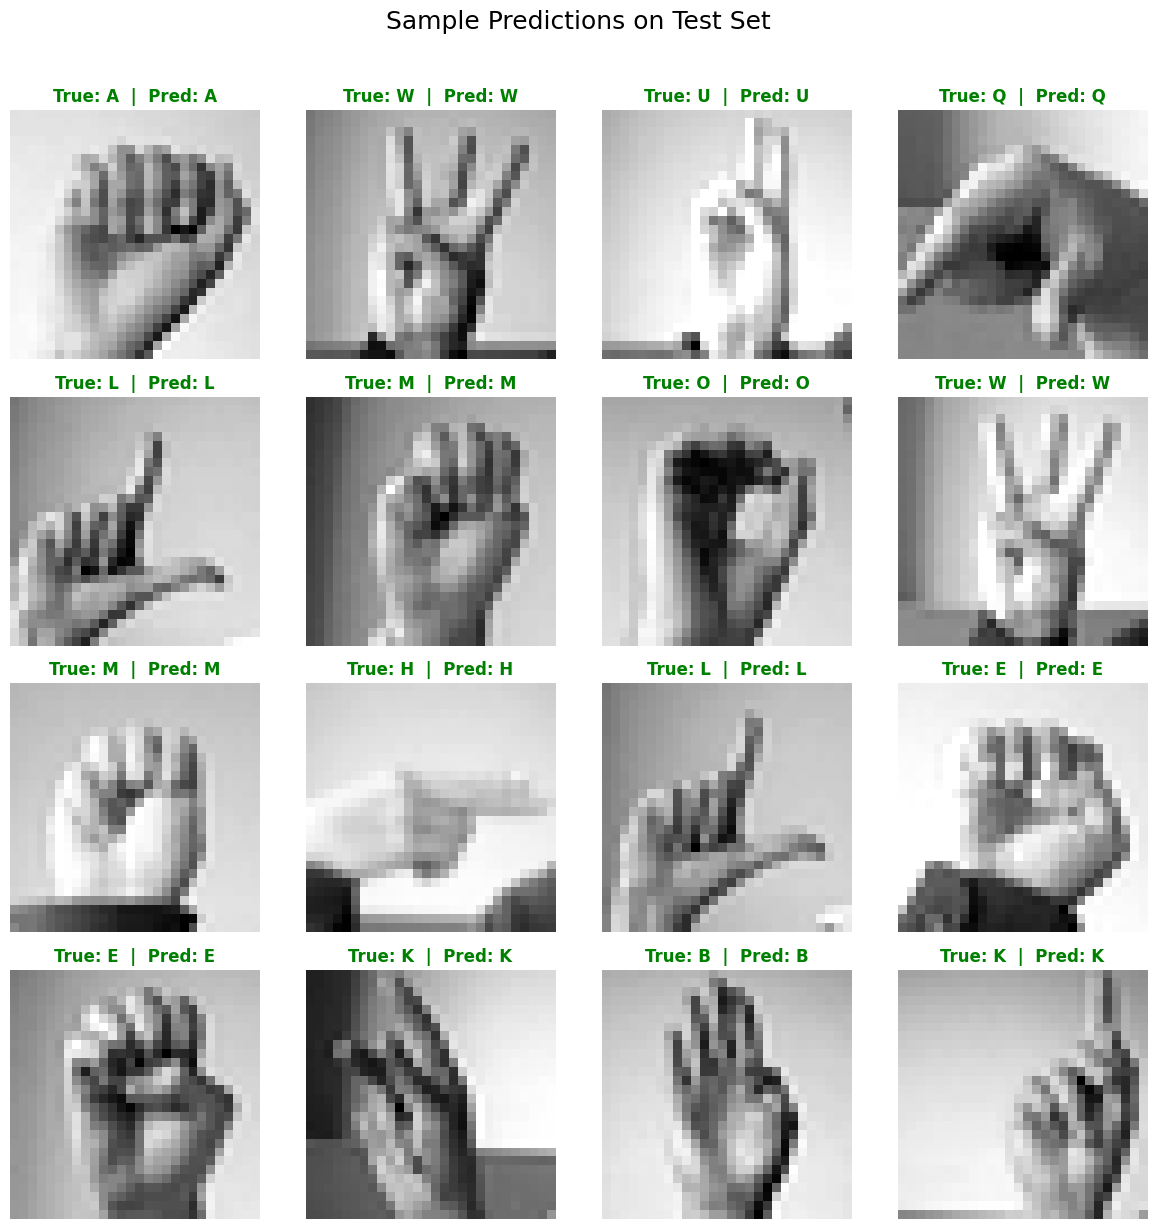

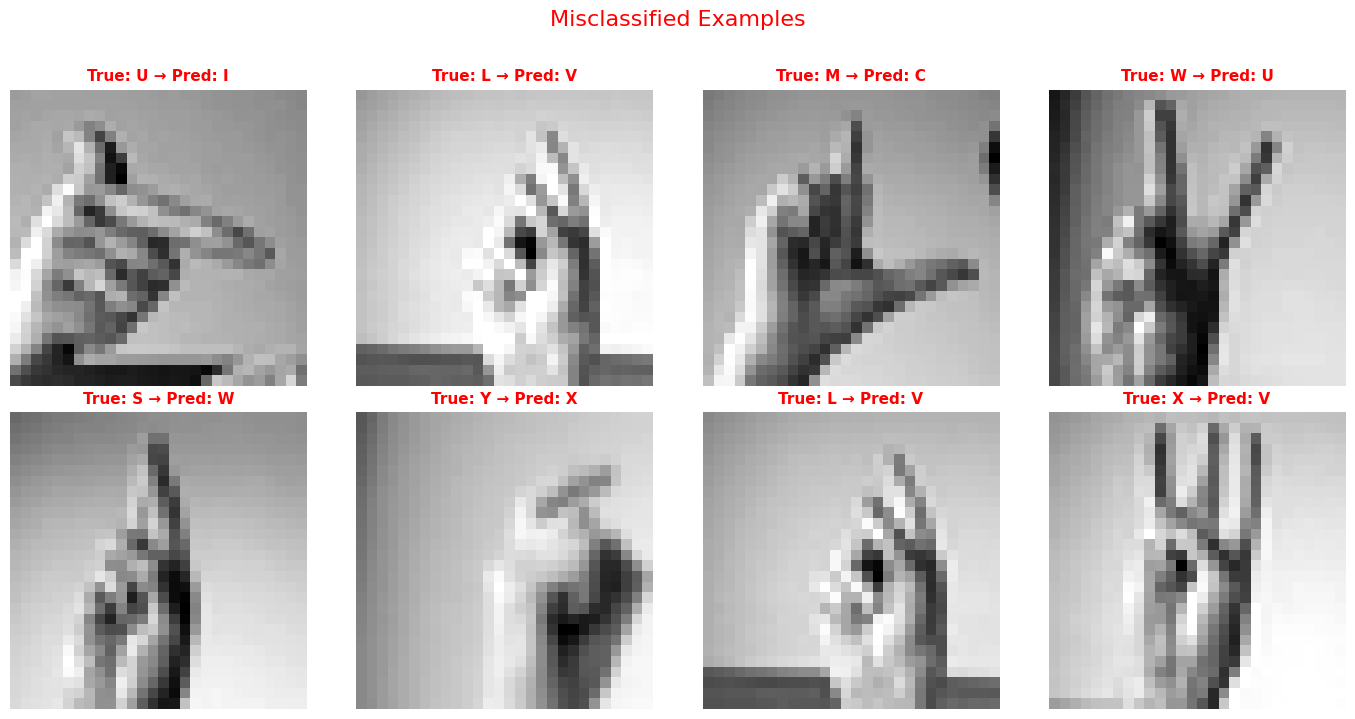

In [20]:
# Sample Predictions – Test Images with true and predicted Labels 
num_samples = 16
random_indices = np.random.choice(len(x_test), num_samples, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample Predictions on Test Set', fontsize=18, y=1.02)

for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    ax.imshow(np.squeeze(x_test[idx]), cmap='gray')
    true_label = label_lookup[y_true[idx]]
    pred_label = label_lookup[y_pred[idx]]
    correct = y_true[idx] == y_pred[idx]
    color = 'green' if correct else 'red'
    ax.set_title(f'True: {true_label}  |  Pred: {pred_label}',
                 color=color, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Show a few misclassified examples
misclassified = np.where(y_pred != y_true)[0]
if len(misclassified) > 0:
    num_mis = min(8, len(misclassified))
    mis_indices = np.random.choice(misclassified, num_mis, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle('Misclassified Examples', fontsize=16, color='red', y=1.02)

    for i, ax in enumerate(axes.flat):
        if i < num_mis:
            idx = mis_indices[i]
            ax.imshow(np.squeeze(x_test[idx]), cmap='gray')
            true_label = label_names[y_true[idx]]
            pred_label = label_names[y_pred[idx]]
            ax.set_title(f'True: {true_label} → Pred: {pred_label}',
                         color='red', fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples found!")